# UTM frame review: EIGSEP survey alignment and true azimuth

**Review companion for [PR #28](https://github.com/EIGSEP/eigsep_terrain/pull/28).**

This notebook gives Aaron one place to inspect the terrain consequences of the
coordinate change and cross-check the July 2024 survey against field notes and
photographs. It contains executed plots; use **Restart Kernel and Run All** after
editing the inputs below. No files are downloaded and no calibration is applied
to the package by this notebook.

The question is whether **UTM with zero horizontal survey correction places known
physical features more accurately than the legacy conversion with `[-11, 36] m`**.
A difference between those predictions cannot answer that question by itself.

We compare:
- **Legacy raw:** tangent-plane coordinates, no horizontal correction.
- **Legacy corrected:** tangent-plane coordinates minus `[-11, 36] m`.
- **UTM zero:** GeoTIFF-based coordinates, no horizontal correction.

The available five points are labelled as July 2024 survey points in
`EIGSEP Suspension and Horizon Modeling.ipynb`; it is **not established** which
points were used to calibrate the historical offset. Their corresponding terrain
features have not been independently identified here. The later EIGSEP horizon
site and MISTIC coordinate are included for context, not as calibration controls.

**Evidence status:** raster metadata and the azimuth convention can be checked
now. Survey accuracy, the remaining field offset, and photographic azimuth
agreement require independent references. Empty reference tables below mean
*unvalidated*, not *zero error*.

## 1. Setup and provenance

Run with an environment containing the PR version of `eigsep_terrain`,
`matplotlib`, `nbformat`, and a Jupyter Python kernel. This notebook explicitly
imports the checkout's `src/` code. Set `EIGSEP_MARJUM_DEM_INPUTS` to `marjum-2026-07/derived/dem/v0002/inputs`
when running from a separate package worktree. The notebook uses the twelve
published v0001/v0002 source tiles (east indices 91–93, north indices 45–48),
with the historical southwest tile 9145 as origin. It checks their SHA-256
hashes against the v0002 manifest.

All plot axes are **local UTM grid metres**, referenced to the southwest pixel
centre. The scalar geographic inputs are interpreted in the raster's NAD83(2011)
datum; GPS datum/epoch remains an item for Aaron to confirm. We preserve the same
raster array indices when comparing legacy and new placements, including the
new explicit half-pixel georeferencing.

In [1]:
from pathlib import Path
import sys, os, json, hashlib, subprocess, platform, copy
from datetime import datetime, timezone
import html
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from matplotlib.patches import Circle
from IPython.display import display, HTML, Markdown
from pyproj import Geod
import pyproj
import PIL
import pyuvdata

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/eigsep_terrain/dem.py").exists())
sys.path.insert(0, str(ROOT / "src"))
from eigsep_terrain.dem import DEM

DATA_DIR = Path(os.environ.get(
    "EIGSEP_MARJUM_DEM_INPUTS",
    ROOT.parent / "marjum-2026-07/derived/dem/v0002/inputs"))
EAST_TILES = range(91, 94)
NORTH_TILES = range(45, 49)
BASE = "USGS_OPR_UT_WestEast_B22_12STJ"
PLOT_DIR = ROOT / "notebooks" / ".ipynb_checkpoints" / "utm_review_figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# Small HTML tables avoid a pandas dependency.
def table(rows, columns):
    def fmt(v):
        if isinstance(v, (float, np.floating)):
            return f"{v:.3f}"
        return str(v)
    body = "".join("<tr>" + "".join(
        f"<td>{html.escape(fmt(row.get(c, '')))}</td>" for c in columns)
        + "</tr>" for row in rows)
    header = "".join(f"<th>{html.escape(c)}</th>" for c in columns)
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

def finish(fig, name):
    fig.savefig(PLOT_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

files = np.array([[str(DATA_DIR / f"{BASE}{e:02d}{n:02d}.tif")
                   for n in NORTH_TILES] for e in EAST_TILES])
xml = DATA_DIR / f"{BASE}9145.xml"
missing = [p for p in [*files.ravel(), str(xml)] if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Provide the v0002 source tiles in "
                            "EIGSEP_MARJUM_DEM_INPUTS. Missing: "
                            + ", ".join(missing))
manifest = json.loads((DATA_DIR.parent / "manifest.json").read_text())
assert manifest["version"] == "v0002"
for path in [*files.ravel(), str(xml)]:
    path = Path(path)
    assert hashlib.sha256(path.read_bytes()).hexdigest() == manifest["input_sha256"][path.name]
dem = DEM()
dem.load_xml(xml)
dem.load_tif(files, survey_offset=(0, 0, 0))
assert np.isclose(dem.res, 0.5)
assert dem.data.shape == (8000, 6000)
assert np.allclose(dem.raster_origin, [291000.25, 4345000.25])
assert dem.crs.to_epsg() == 6341

def git(*args):
    return subprocess.check_output(["git", "-C", str(ROOT), *args], text=True).strip()

provenance = {
    "executed_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": git("rev-parse", "HEAD"),
    "tracked_code_changes": git("diff", "--name-only", "HEAD", "--", "src"),
    "python": platform.python_version(), "numpy": np.__version__,
    "pyproj": pyproj.__version__, "pyuvdata": pyuvdata.__version__,
    "crs": dem.crs.to_string(), "geographic_datum": dem.crs.geodetic_crs.name,
    "raster_origin_utm_m": dem.raster_origin.tolist(),
    "shape_north_east": list(dem.data.shape), "pixel_size_m": float(dem.res),
    "xml_sha256": hashlib.sha256(xml.read_bytes()).hexdigest(),
    "dem_product_sha256": manifest["files"]["marjum_dem.npz"]["sha256"],
}
print(json.dumps(provenance, indent=2))
print("Source tiles:", ", ".join(Path(p).stem[-4:] for p in files.ravel()))
print("Terrain range (m):", np.nanmin(dem.data), np.nanmax(dem.data))

{
  "executed_utc": "2026-10-07T18:01:23.576619+00:00",
  "code_commit": "57e39396d285f247b5ae06c0fc51d0c0f9d405fd",
  "tracked_code_changes": "",
  "python": "3.11.11",
  "numpy": "2.2.6",
  "pyproj": "3.7.2",
  "pyuvdata": "3.2.7",
  "crs": "EPSG:6341",
  "geographic_datum": "NAD83(2011)",
  "raster_origin_utm_m": [
    291000.25,
    4345000.25
  ],
  "shape_north_east": [
    8000,
    6000
  ],
  "pixel_size_m": 0.5,
  "xml_sha256": "04aa65f99a502c450a2ee11f26711fb2b1ebf3a6e5c2eb0a2cabab32efe64b5b",
  "dem_product_sha256": "e890231c970be4ed690ccc443f1b80a9a74a553f963b4ebc16b180c34a91b2f8"
}
Source tiles: 9145, 9146, 9147, 9148, 9245, 9246, 9247, 9248, 9345, 9346, 9347, 9348
Terrain range (m): 1485.1726 2269.9575


## 2. Review inputs — edit here

The GPS coordinates and descriptions below are transcribed from the repository's
survey notebook. Point A and B are reported **about 3 m south of the antennas**;
match the survey mark, or explicitly account for that displacement. The MISTIC
coordinate is approximate, as in the bug report.

### Independent terrain matches

After examining photos/notes, enter the local raster `(e_m, n_m)` of the **same
physical survey point**. These coordinates can be read from the detailed plots
below. If using a GIS with EPSG:6341 coordinates, subtract
`dem.raster_origin` to obtain local coordinates. Check pixel-centre versus edge
conventions. Do not choose a reference simply because it coincides with one of
the predicted markers.

Give each match a combined horizontal uncertainty (`sigma_m`, including GPS and
feature identification), source, and role. Choose `fit` points to estimate a
translation and independent `check` points to evaluate it. Repeat with alternative
plausible matches to expose judgment sensitivity. A successful in-sample fit is
not evidence of improved accuracy away from those points.

### Observed true bearings

Enter a recognizable landmark's independently identified raster location and a
**true bearing** measured at a listed observer point. Establish photo orientation
independently; a freely fitted yaw can absorb the error we are trying to measure.
Magnetic bearings need their own documented conversion to true north. Include
position uncertainty in the bearing uncertainty when it matters.

In [2]:
POINTS = [
    dict(id="0724 A", lat=39.241127, lon=-113.392966, alt=1748,
         description="survey mark ~3 m south of antenna 1", group="survey"),
    dict(id="0724 B", lat=39.239895, lon=-113.395416, alt=1728,
         description="survey mark ~3 m south of antenna 2", group="survey"),
    dict(id="0724 O", lat=39.241514, lon=-113.395236, alt=1804,
         description="outlook, west canyon", group="survey"),
    dict(id="0724 W", lat=39.241107, lon=-113.395233, alt=1790,
         description="west anchor", group="survey"),
    dict(id="0724 E", lat=39.240712, lon=-113.393846, alt=1776,
         description="east anchor", group="survey"),
    dict(id="EIGSEP later", lat=39.247907, lon=-113.402715, alt=None,
         description="EIGSEP Horizons notebook coordinate", group="context"),
    dict(id="MISTIC approx", lat=39.2489, lon=-113.4024, alt=None,
         description="approximate coordinate in bug report", group="context"),
]
MATCHES = [
    # dict(id="0724 W", e_m=..., n_m=..., sigma_m=..., role="fit",
    #      source="Aaron: photo/date/feature and GPS accuracy notes"),
    # dict(id="0724 E", e_m=..., n_m=..., sigma_m=..., role="check",
    #      source="Independent withheld terrain match"),
]
OBSERVED_BEARINGS = [
    # dict(observer="0724 W", landmark="named ridge",
    #      landmark_e_m=..., landmark_n_m=..., true_az_deg=...,
    #      sigma_deg=..., source="photo/compass alignment and datum notes"),
]
# Heights are diagnostic until GPS vertical datum / geoid and antenna height
# above the measured surface are understood. This is NOT a vertical fit.
SURVEY_VERTICAL_SUBTRACTION_M = 3.0
RUN_HORIZON_PREVIEW = True
PREVIEW_DECIMATION = 8  # 4 m sample spacing, NOT production resolution
PREVIEW_N_AZ = 1440
PREVIEW_OBSERVER = "EIGSEP later"
# Optional independently known DEM-datum observer altitude. None uses a
# hypothetical observer 2 m above UTM-zero terrain for sensitivity only.
PREVIEW_OBSERVER_ALT_M = None

ids = [p["id"] for p in POINTS]
assert len(set(ids)) == len(ids)
assert len({m["id"] for m in MATCHES}) == len(MATCHES), "One match per survey point"
for m in MATCHES:
    assert m["id"] in ids and m["role"] in ("fit", "check")
    assert m["sigma_m"] > 0 and m["source"].strip()
    assert np.isfinite([m["e_m"], m["n_m"], m["sigma_m"]]).all()
for b in OBSERVED_BEARINGS:
    assert b["observer"] in ids and b["sigma_deg"] > 0 and b["source"].strip()
    assert np.isfinite([b[k] for k in
                       ("landmark_e_m", "landmark_n_m", "true_az_deg", "sigma_deg")]).all()
print(f"Independent terrain matches: {len(MATCHES)}; observed bearings: {len(OBSERVED_BEARINGS)}")
if not MATCHES:
    display(Markdown("**Field translation and physical placement: awaiting references.**"))
if not OBSERVED_BEARINGS:
    display(Markdown("**Observed true-azimuth agreement: awaiting references.**"))

Independent terrain matches: 0; observed bearings: 0


**Field translation and physical placement: awaiting references.**

**Observed true-azimuth agreement: awaiting references.**

## 3. Predicted positions and coordinate differences

The legacy calculation below is copied explicitly from the pre-PR coordinate
formula, using the same XML origin. It does not call the new UTM conversion.
The table compares horizontal placements on the **same raster**. All distances
in this section are disagreements between mappings, not measured physical errors.
The fixed `[-11, 36] m` correction is subtracted from the old coordinates.

The original legacy altitude conversion also mixed tangent-plane curvature with
height. We deliberately isolate horizontal placement here; later elevation
comparisons use a common survey height convention.

In [3]:
def legacy_en(lat, lon, offset=(0, 0)):
    xyz = pyuvdata.utils.XYZ_from_LatLonAlt(np.deg2rad(lat), np.deg2rad(lon), 0)
    enu = pyuvdata.utils.ENU_from_ECEF(
        xyz, latitude=dem.map_crd["southbc"],
        longitude=dem.map_crd["westbc"], altitude=0)
    return np.asarray(enu[:2]) - np.asarray(offset)

methods = ["Legacy raw", "Legacy corrected", "UTM zero"]
styles = {"Legacy raw": ("#d49b00", "x"),
          "Legacy corrected": ("#c43b55", "s"),
          "UTM zero": ("#087cba", "o")}
positions = {}
for p in POINTS:
    positions[p["id"]] = {
        "Legacy raw": legacy_en(p["lat"], p["lon"]),
        "Legacy corrected": legacy_en(p["lat"], p["lon"], (-11, 36)),
        "UTM zero": dem.latlon_to_raster(p["lat"], p["lon"], survey_offset=0)[:2],
    }
rows = []
for p in POINTS:
    v = positions[p["id"]]
    delta = v["Legacy corrected"] - v["UTM zero"]
    rows.append(dict(point=p["id"], description=p["description"],
        new_E=v["UTM zero"][0], new_N=v["UTM zero"][1],
        old_minus_new_E=delta[0], old_minus_new_N=delta[1],
        corrected_disagreement_m=np.linalg.norm(delta),
        raw_disagreement_m=np.linalg.norm(v["Legacy raw"]-v["UTM zero"])))
table(rows, ["point", "description", "new_E", "new_N", "old_minus_new_E",
             "old_minus_new_N", "corrected_disagreement_m", "raw_disagreement_m"])
# Explicitly check our copied legacy formula against the compatibility path.
for p in POINTS:
    np.testing.assert_allclose(positions[p["id"]]["Legacy corrected"],
        dem.latlon_to_enu(p["lat"], p["lon"], frame="tangent",
                         survey_offset=np.array([-11, 36, 3]))[:2], atol=1e-8)

point,description,new_E,new_N,old_minus_new_E,old_minus_new_N,corrected_disagreement_m,raw_disagreement_m
0724 A,survey mark ~3 m south of antenna 1,2481.649,1263.995,2.971,29.987,30.134,66.474
0724 B,survey mark ~3 m south of antenna 2,2266.565,1132.842,6.581,24.299,25.175,60.461
0724 O,"outlook, west canyon",2286.857,1312.132,1.778,24.755,24.819,61.451
0724 W,west anchor,2285.921,1266.950,2.986,24.752,24.932,61.278
0724 E,east anchor,2404.476,1219.941,4.186,27.945,28.257,64.307
EIGSEP later,EIGSEP Horizons notebook coordinate,1660.167,2038.834,-17.351,7.644,18.960,52.044
MISTIC approx,approximate coordinate in bug report,1690.278,2148.331,-20.294,8.396,21.962,54.317


## 4. Terrain overlays for matching field photographs

Colours and markers are consistent throughout. Terrain is shown as elevation
with hillshade and contours. The overview is decimated for display; local panels
use native 0.5 m pixels. Black stars and uncertainty circles appear only after
independent `MATCHES` are entered. Grid north is up; a true-north arrow is shown
on the overview. Re-run with narrower limits or use a Jupyter interactive
Matplotlib backend to inspect a feature more closely.

**Aaron:** identify the actual survey mark/anchor/outlook before selecting its
reference coordinate. Describe why the feature is recognizable and whether the
GPS point was displaced from it. Hillshade alone may not identify a small anchor.

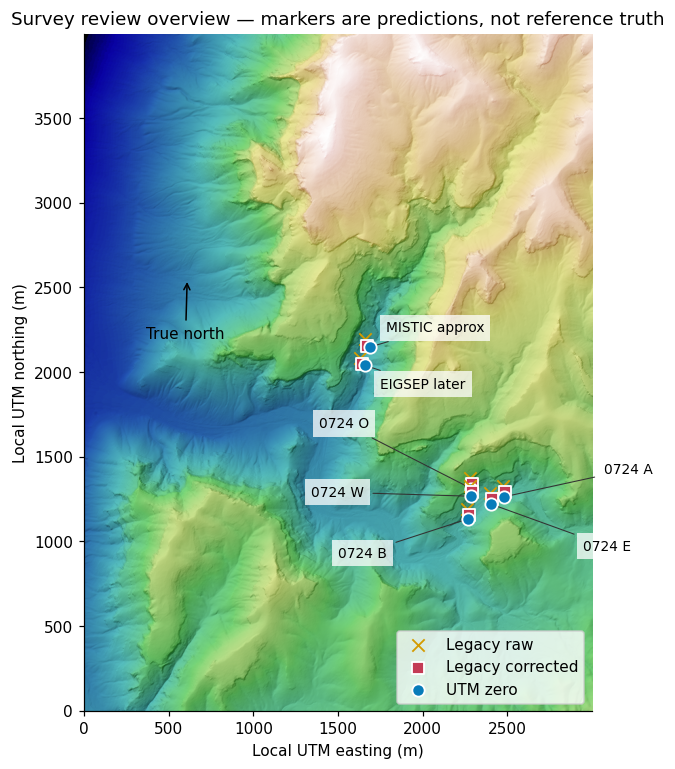

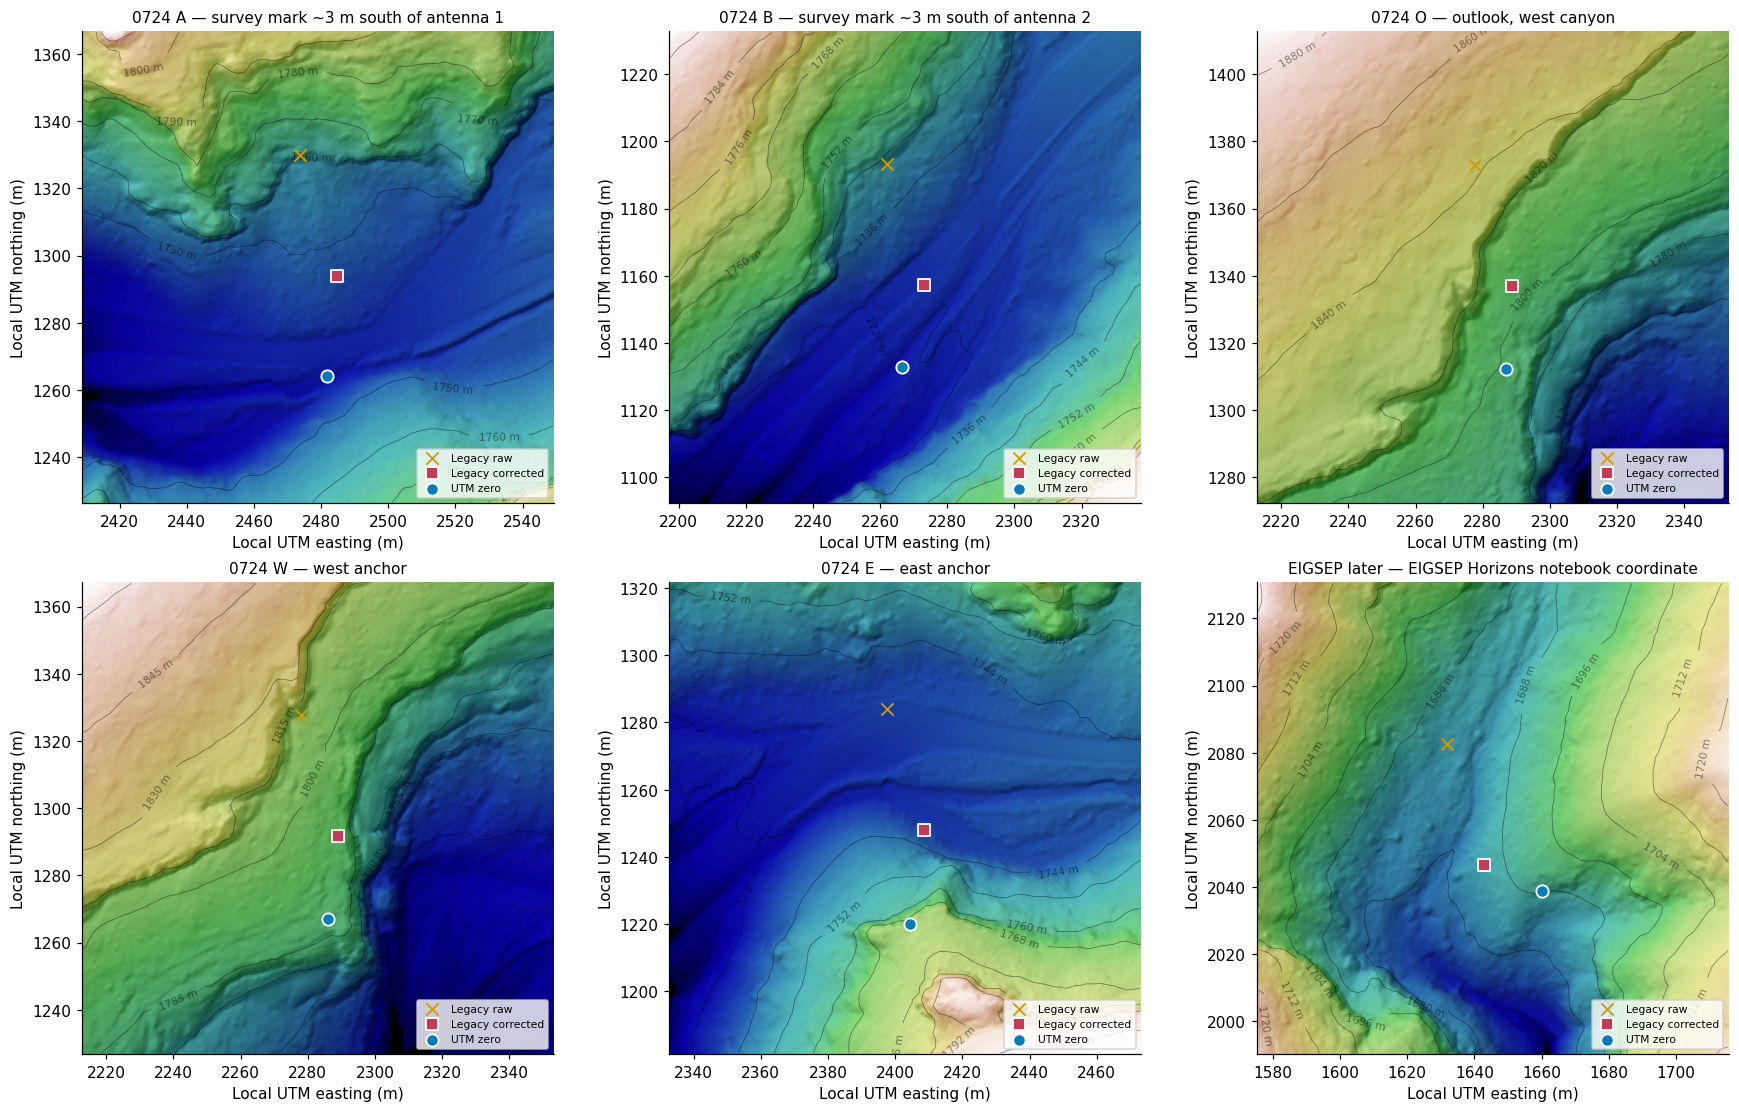

In [4]:
def terrain(ax, bounds=None, stride=1):
    if bounds is None:
        e0, e1, n0, n1 = 0, dem.data.shape[1]*dem.res, 0, dem.data.shape[0]*dem.res
    else:
        e0, e1, n0, n1 = bounds
    i0, i1 = max(0, int(e0/dem.res)), min(dem.data.shape[1], int(e1/dem.res)+1)
    j0, j1 = max(0, int(n0/dem.res)), min(dem.data.shape[0], int(n1/dem.res)+1)
    e = np.arange(i0, i1, stride)*dem.res
    n = np.arange(j0, j1, stride)*dem.res
    z = dem.data[j0:j1:stride, i0:i1:stride]
    z = np.where(z < -1000, np.nan, z)
    spacing = dem.res*stride
    # Flip to north-up image before lighting so hillshade direction is correct.
    rgb = LightSource(azdeg=315, altdeg=45).shade(
        np.flipud(z), cmap=plt.get_cmap("gist_earth"),
        dx=spacing, dy=spacing, vert_exag=1, blend_mode="soft")
    ax.imshow(rgb, origin="upper", extent=(e[0]-spacing/2, e[-1]+spacing/2,
                                           n[0]-spacing/2, n[-1]+spacing/2))
    if bounds is not None:
        contours = ax.contour(e[::4], n[::4], z[::4, ::4],
                             levels=8, colors="black", alpha=.45, linewidths=.5)
        ax.clabel(contours, fontsize=7, fmt="%.0f m")
    ax.set(xlabel="Local UTM easting (m)", ylabel="Local UTM northing (m)")
    ax.set_aspect("equal")
    return ax

def plot_predictions(ax, point_id, label=False):
    for method, en in positions[point_id].items():
        color, marker = styles[method]
        ax.scatter(*en, s=65, c=color, marker=marker,
                   edgecolors="white" if marker != "x" else None,
                   linewidths=1.2, label=method if label else None, zorder=5)
    for m in MATCHES:
        if m["id"] == point_id:
            ax.scatter(m["e_m"], m["n_m"], marker="*", c="black", s=130,
                       label="Independent reference" if label else None, zorder=6)
            ax.add_patch(Circle((m["e_m"], m["n_m"]), m["sigma_m"],
                                fill=False, color="black", linestyle=":"))

fig, ax = plt.subplots(figsize=(10, 8))
terrain(ax, stride=8)
label_offsets = {"0724 A": (65, 15), "0724 B": (-85, -25),
                 "0724 O": (-100, 40), "0724 W": (-105, 0),
                 "0724 E": (60, -30), "EIGSEP later": (10, -15),
                 "MISTIC approx": (10, 10)}
for i,p in enumerate(POINTS):
    plot_predictions(ax, p["id"], label=(i==0))
    ax.annotate(p["id"], positions[p["id"]]["UTM zero"],
                xytext=label_offsets[p["id"]], textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="-", lw=.7, color="0.2"),
                bbox=dict(facecolor="white", alpha=.75, edgecolor="none"))
gamma = dem.grid_convergence(*positions["0724 W"]["UTM zero"])
base = np.array([600., 2200.])
true_north = np.array([-np.sin(gamma), np.cos(gamma)])*350
ax.annotate("True north", base+true_north, xytext=base,
            arrowprops=dict(arrowstyle="->", color="black"), ha="center")
ax.set_title("Survey review overview — markers are predictions, not reference truth")
ax.legend(loc="lower right")
finish(fig, "01_overview")

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax,p in zip(axes.flat, POINTS[:6]):
    v = np.array(list(positions[p["id"]].values()))
    refs = [[m["e_m"], m["n_m"]] for m in MATCHES if m["id"] == p["id"]]
    if refs:
        v = np.vstack([v, refs])
    centre = (v.min(axis=0)+v.max(axis=0))/2
    half = max(70, np.ptp(v, axis=0).max()/2+35)
    terrain(ax, (centre[0]-half, centre[0]+half, centre[1]-half, centre[1]+half))
    plot_predictions(ax, p["id"], label=True)
    ax.set_title(p["id"]+" — "+p["description"], fontsize=10)
    ax.legend(fontsize=7, loc="lower right")
finish(fig, "02_local_overlays")

## 5. How much of the mapping difference is a translation?

Here we estimate a **mapping-equivalence translation**, using the five July 2024
points: `legacy_corrected ≈ UTM_zero + t`. This answers how large a new shift
would be needed to reproduce the old placements locally. It is **not** an
estimate of the physical survey correction, because the old placements are not
independent truth.

The package convention subtracts `survey_offset`, so an added translation `t`
corresponds to a horizontal offset `-t`. Residual variation across points exposes
what one constant translation cannot reproduce. Context sites are withheld from
this fit and illustrate its limited geographic reach.

Translation added to UTM to reproduce legacy locally (E,N), m: [ 3.70039222 26.3477845 ]
Equivalent SUBTRACTED survey_offset (E,N), m: [ -3.70039222 -26.3477845 ]
This is mapping equivalence, not a field calibration.


point,role,residual_E_m,residual_N_m,residual_norm_m
0724 A,survey,-0.730,3.639,3.712
0724 B,survey,2.881,-2.048,3.535
0724 O,survey,-1.923,-1.592,2.497
0724 W,survey,-0.714,-1.596,1.748
0724 E,survey,0.486,1.597,1.669
EIGSEP later,context,-21.051,-18.704,28.160
MISTIC approx,context,-23.994,-17.952,29.967


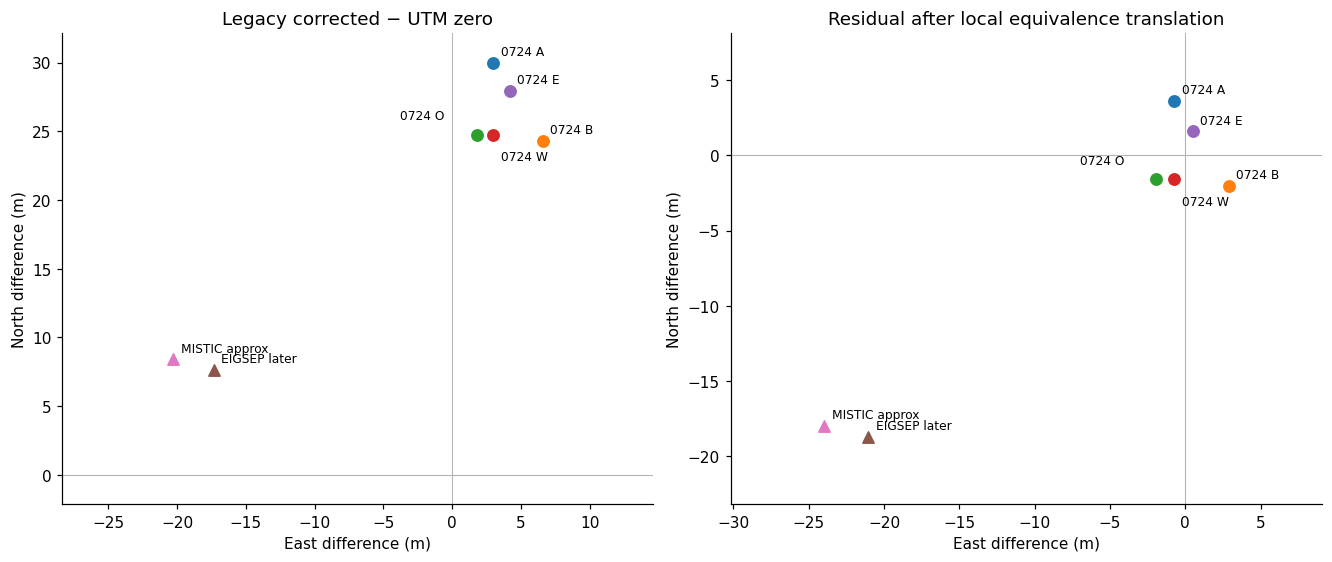

In [5]:
survey_ids = [p["id"] for p in POINTS if p["group"] == "survey"]
delta = np.array([positions[i]["Legacy corrected"]-positions[i]["UTM zero"]
                  for i in survey_ids])
t_equiv = delta.mean(axis=0)
print("Translation added to UTM to reproduce legacy locally (E,N), m:", t_equiv)
print("Equivalent SUBTRACTED survey_offset (E,N), m:", -t_equiv)
print("This is mapping equivalence, not a field calibration.")
rows = []
for p in POINTS:
    d = positions[p["id"]]["Legacy corrected"]-positions[p["id"]]["UTM zero"]
    r = d-t_equiv
    rows.append(dict(point=p["id"], role=p["group"],
                     residual_E_m=r[0], residual_N_m=r[1],
                     residual_norm_m=np.linalg.norm(r)))
table(rows, ["point", "role", "residual_E_m", "residual_N_m", "residual_norm_m"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, shift, title in zip(axes, [np.zeros(2), t_equiv],
        ["Legacy corrected − UTM zero", "Residual after local equivalence translation"]):
    for p in POINTS:
        d = positions[p["id"]]["Legacy corrected"]-positions[p["id"]]["UTM zero"]-shift
        ax.scatter(*d, marker="o" if p["group"]=="survey" else "^", s=55)
        offset = {"0724 O": (-50, 10), "0724 W": (5, -17)}.get(p["id"], (5, 5))
        ax.annotate(p["id"], d, xytext=offset, textcoords="offset points", fontsize=8)
    ax.axhline(0, color="0.7", lw=.7); ax.axvline(0, color="0.7", lw=.7)
    ax.set(xlabel="East difference (m)", ylabel="North difference (m)", title=title)
    ax.set_aspect("equal", adjustable="datalim"); ax.margins(.3)
finish(fig, "03_mapping_translation")

## 6. Field translation and held-out validation — needs Aaron's matches

For each method we report residuals **prediction minus reference**. We fit one
translation using only `role="fit"` matches, weighted by `1/sigma_m²`. The RMS
below is the unweighted two-dimensional RMS in metres, so it is easy to compare
across methods. `check` points never enter the fit. Choose uncertainty based on
the evidence; an ordinary least-squares translation is sensitive to mistaken
feature matches. With very few or clustered points, a good fit cannot establish
accuracy at another canyon site.

A convincing result is that UTM zero already improves independently measured
errors, or that UTM needs a smaller residual translation and achieves lower
**held-out** errors. A smaller fitted offset alone is insufficient. The UTM row's
negative translation is the candidate horizontal `survey_offset`; it is not
saved to the package.

In [6]:
field_results = []
field_translations = {}
if not MATCHES:
    display(Markdown("**Awaiting independent terrain matches. No field offset has been estimated.**"))
else:
    table(MATCHES, ["id", "e_m", "n_m", "sigma_m", "role", "source"])
    fit_mask = np.array([m["role"] == "fit" for m in MATCHES])
    ref = np.array([[m["e_m"], m["n_m"]] for m in MATCHES])
    weights = 1/np.array([m["sigma_m"] for m in MATCHES])**2
    for method in methods:
        pred = np.array([positions[m["id"]][method] for m in MATCHES])
        residual = pred-ref
        t = (-np.average(residual[fit_mask], weights=weights[fit_mask], axis=0)
             if fit_mask.any() else None)
        field_translations[method] = t
        for role in ("fit", "check"):
            mask = np.array([m["role"] == role for m in MATCHES])
            if not mask.any():
                continue
            field_results.append(dict(method=method, role=role, n=int(mask.sum()),
                raw_RMS_m=np.sqrt(np.mean(np.sum(residual[mask]**2, axis=1))),
                translated_RMS_m=(np.sqrt(np.mean(np.sum((residual[mask]+t)**2, axis=1)))
                                  if t is not None else "no fit points"),
                added_E_m=t[0] if t is not None else "",
                added_N_m=t[1] if t is not None else ""))
    table(field_results, ["method", "role", "n", "raw_RMS_m", "translated_RMS_m",
                          "added_E_m", "added_N_m"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for method in methods:
        pred = np.array([positions[m["id"]][method] for m in MATCHES])
        r = pred-ref
        t = field_translations[method]
        for ax, rr in [(axes[0], r), (axes[1], r+t if t is not None else r)]:
            color, marker = styles[method]
            for k,m in enumerate(MATCHES):
                ax.scatter(*rr[k], c=color, marker=marker, s=65,
                           label=method if k==0 else None,
                           alpha=1 if m["role"]=="check" else .45)
                ax.annotate(m["id"]+" ("+m["role"]+")", rr[k], fontsize=7)
    for ax,title in zip(axes, ["Before any new fit", "After translation fit (if available)"]):
        ax.axhline(0, color="0.7"); ax.axvline(0, color="0.7")
        ax.set(title=title, xlabel="Predicted − reference east (m)",
               ylabel="Predicted − reference north (m)")
        ax.set_aspect("equal", adjustable="datalim"); ax.legend(fontsize=8)
    finish(fig, "04_field_residuals")
    if fit_mask.sum() < 2 or not (~fit_mask).any():
        display(Markdown("**Insufficient independent validation: include multiple fit points and held-out check points.**"))
    if field_translations["UTM zero"] is not None:
        print("Candidate UTM horizontal survey_offset (SUBTRACTED):",
              -field_translations["UTM zero"])
        print("Provisional; evaluate check-point errors and source uncertainties first.")

**Awaiting independent terrain matches. No field offset has been estimated.**

## 7. Survey elevations as a secondary diagnostic

The table samples native DEM elevation at each predicted location. It is useful
for recognizing a wrong slope or ridge, but **height agreement does not uniquely
identify a horizontal position**. GPS height may be ellipsoidal, geoid-corrected,
barometric, or a map lookup; the DEM uses its own vertical datum. Until Aaron
confirms this, treat the differences below as diagnostics only. The retained
3 m vertical subtraction is applied equally to all methods and is not fitted.

point,method,recorded_height_m,DEM_height_m,survey_minus_3_minus_DEM_m
0724 A,Legacy raw,1748,1762.518,-17.518
0724 A,Legacy corrected,1748,1747.974,-2.974
0724 A,UTM zero,1748,1742.554,2.446
0724 B,Legacy raw,1728,1740.881,-15.881
0724 B,Legacy corrected,1728,1728.896,-3.896
0724 B,UTM zero,1728,1727.069,-2.069
0724 O,Legacy raw,1804,1841.665,-40.665
0724 O,Legacy corrected,1804,1803.349,-2.349
0724 O,UTM zero,1804,1798.853,2.147
0724 W,Legacy raw,1790,1805.781,-18.781


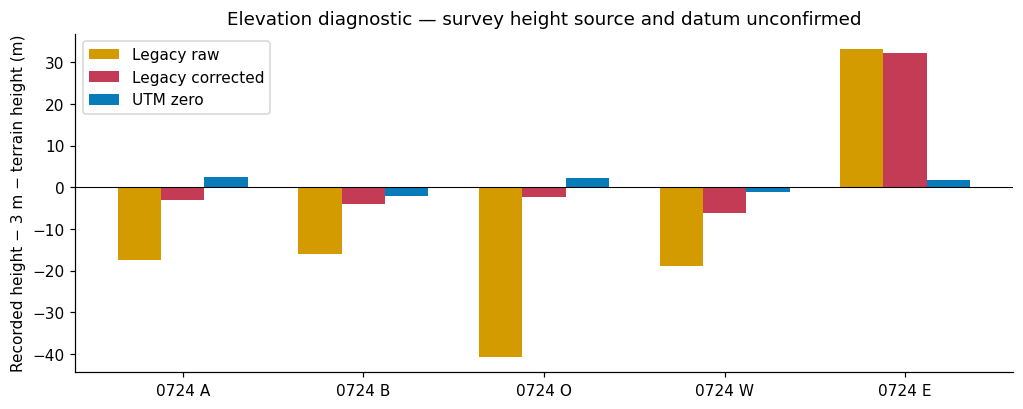

method,diagnostic_height_RMS_m
Legacy raw,27.091
Legacy corrected,14.919
UTM zero,1.950


At the east anchor, the corrected legacy placement is on a substantially lower part of the slope than UTM zero. The elevation agreement is a useful clue for Aaron to check against site photographs. It is not independent evidence if the recorded height was itself obtained from a terrain map.

In [7]:
def sample_height(en):
    e, n = np.rint(np.asarray(en)/dem.res).astype(int)
    if not (0 <= e < dem.data.shape[1] and 0 <= n < dem.data.shape[0]):
        return np.nan
    value = float(dem.data[n, e])
    return value if value > -1000 else np.nan

height_rows = []
for p in POINTS:
    if p["alt"] is None:
        continue
    target = p["alt"]-SURVEY_VERTICAL_SUBTRACTION_M
    for method in methods:
        z = sample_height(positions[p["id"]][method])
        height_rows.append(dict(point=p["id"], method=method, recorded_height_m=p["alt"],
                                DEM_height_m=z, survey_minus_3_minus_DEM_m=target-z))
table(height_rows, ["point", "method", "recorded_height_m", "DEM_height_m",
                    "survey_minus_3_minus_DEM_m"])
fig, ax = plt.subplots(figsize=(11, 4))
for k,method in enumerate(methods):
    rr = [r for r in height_rows if r["method"] == method]
    ax.bar(np.arange(len(rr))+(k-1)*.24,
           [r["survey_minus_3_minus_DEM_m"] for r in rr],
           width=.24, color=styles[method][0], label=method)
ax.axhline(0, color="black", lw=.7)
ax.set_xticks(range(len(survey_ids)), survey_ids)
ax.set(ylabel="Recorded height − 3 m − terrain height (m)",
       title="Elevation diagnostic — survey height source and datum unconfirmed")
ax.legend(); finish(fig, "04b_height_diagnostic")
height_rms = {}
for method in methods:
    rr = np.array([r["survey_minus_3_minus_DEM_m"] for r in height_rows
                   if r["method"] == method])
    height_rms[method] = np.sqrt(np.mean(rr**2))
table([dict(method=m, diagnostic_height_RMS_m=v) for m,v in height_rms.items()],
      ["method", "diagnostic_height_RMS_m"])
display(Markdown(
    "At the east anchor, the corrected legacy placement is on a substantially "
    "lower part of the slope than UTM zero. The elevation agreement is a useful "
    "clue for Aaron to check against site photographs. It is not independent "
    "evidence if the recorded height was itself obtained from a terrain map."
))


## 8. Azimuth convention: independent geodesic and synthetic terrain checks

First compare a UTM grid bearing plus observer convergence against an ellipsoidal
geodesic bearing between the survey coordinates. This checks the sign and local
projection approximation; it does **not** verify the surveyed coordinates or an
actual photograph. The notebook uses the raster datum's ellipsoid.

Then create a synthetic tall pillar and check that `calc_horizon` places its peak
at the independent geodesic bearing. Grid and true bearings straddle the north
wraparound here. A finite pixel covers an angular interval, so compare the
centre of its support with a tolerance set by pixel size and bin width.

target,distance_m,grid_deg,convergence_deg,geodesic_true_deg,corrected_minus_geodesic_deg
0724 A,195.726,90.865,-1.516,89.349,-0.000
0724 B,135.481,-171.788,-1.516,-173.303,-0.000
0724 O,45.186,1.187,-1.516,-0.328,0.000
0724 E,127.520,111.629,-1.516,110.114,-0.000
EIGSEP later,993.539,-39.031,-1.516,-40.547,0.000
MISTIC approx,1063.641,-34.051,-1.516,-35.567,0.000


Synthetic pillar: geodesic bearing -1.5773°, peak support centre -1.6250°


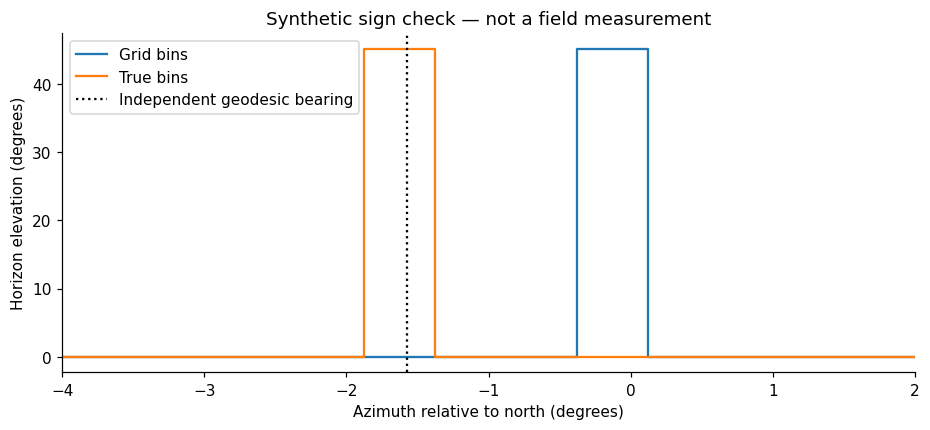

In [8]:
geod = dem.crs.get_geod()
def wrap_deg(a):
    return (np.asarray(a)+180)%360-180

a = next(p for p in POINTS if p["id"]=="0724 W")
rows = []
for b in POINTS:
    if b["id"] == a["id"]:
        continue
    bearing, _, distance = geod.inv(a["lon"], a["lat"], b["lon"], b["lat"])
    d = positions[b["id"]]["UTM zero"]-positions[a["id"]]["UTM zero"]
    grid = np.rad2deg(np.arctan2(d[0], d[1]))
    gamma = np.rad2deg(dem.grid_convergence(*positions[a["id"]]["UTM zero"]))
    rows.append(dict(target=b["id"], distance_m=distance, grid_deg=grid,
                     convergence_deg=gamma, geodesic_true_deg=bearing,
                     corrected_minus_geodesic_deg=float(wrap_deg(grid+gamma-bearing))))
table(rows, ["target", "distance_m", "grid_deg", "convergence_deg",
             "geodesic_true_deg", "corrected_minus_geodesic_deg"])

synthetic = copy.copy(dem)
synthetic.data = np.full((160, 160), -100., dtype=np.float32)
synthetic.res = 1.
synthetic.e0_px = synthetic.n0_px = 0
synthetic.raster_origin = np.array(dem._forward.transform(-113.4024, 39.2489))
synthetic.data[130, 80] = 100.
observer = np.array([80.1, 30.1, 0.])
lat0, lon0, _ = synthetic.raster_to_latlon(observer)
lat1, lon1, _ = synthetic.raster_to_latlon([80, 130, 100])
expected, _, _ = geod.inv(lon0, lat0, lon1, lat1)
az = np.arange(1440)*360/1440
htrue, _ = synthetic.calc_horizon(*observer, n_az=1440)
hgrid, _ = synthetic.calc_horizon(*observer, n_az=1440, azimuth_frame="grid")
peak = np.rad2deg(np.angle(np.mean(np.exp(1j*np.deg2rad(az[htrue>0])))))
assert abs(float(wrap_deg(peak-expected))) < .3
print(f"Synthetic pillar: geodesic bearing {expected:.4f}°, peak support centre {peak:.4f}°")
fig, ax = plt.subplots(figsize=(10, 4))
x = wrap_deg(az); order = np.argsort(x)
ax.step(x[order], np.rad2deg(hgrid[order]), where="mid", label="Grid bins")
ax.step(x[order], np.rad2deg(htrue[order]), where="mid", label="True bins")
ax.axvline(expected, color="black", linestyle=":", label="Independent geodesic bearing")
ax.set(xlim=(-4, 2), xlabel="Azimuth relative to north (degrees)",
       ylabel="Horizon elevation (degrees)", title="Synthetic sign check — not a field measurement")
ax.legend(); finish(fig, "05_synthetic_azimuth")

## 9. Observed landmark bearings — needs field/photo references

For a fixed landmark on the raster, compare the historically labelled bearing
(`atan2` in raster axes at the legacy-corrected observer) and the PR bearing
(`atan2 + convergence` at the UTM-zero observer). Also report the UTM grid bearing
so the position change and north correction can be distinguished. No heading
or translation is fitted in this section. If calibration moves the observer,
repeat this check with the calibrated observer explicitly; don't silently absorb
that movement into photo orientation.

In [9]:
bearing_rows = []
for b in OBSERVED_BEARINGS:
    target = np.array([b["landmark_e_m"], b["landmark_n_m"]])
    old = positions[b["observer"]]["Legacy corrected"]
    new = positions[b["observer"]]["UTM zero"]
    do, dn = target-old, target-new
    if min(np.linalg.norm(do), np.linalg.norm(dn)) < 1:
        raise ValueError("Choose a landmark distinct from the observer")
    old_grid = np.rad2deg(np.arctan2(do[0], do[1]))
    new_grid = np.rad2deg(np.arctan2(dn[0], dn[1]))
    new_true = new_grid+np.rad2deg(dem.grid_convergence(*new))
    bearing_rows.append(dict(observer=b["observer"], landmark=b["landmark"],
        observed_true_deg=b["true_az_deg"], sigma_deg=b["sigma_deg"],
        old_label_error_deg=float(wrap_deg(old_grid-b["true_az_deg"])),
        new_grid_error_deg=float(wrap_deg(new_grid-b["true_az_deg"])),
        new_true_error_deg=float(wrap_deg(new_true-b["true_az_deg"])), source=b["source"]))
if bearing_rows:
    table(bearing_rows, ["observer", "landmark", "observed_true_deg", "sigma_deg",
                        "old_label_error_deg", "new_grid_error_deg", "new_true_error_deg", "source"])
    fig, ax = plt.subplots(figsize=(11, 4))
    for k,(key,label) in enumerate([("old_label_error_deg", "Legacy corrected / grid label"),
                                   ("new_grid_error_deg", "UTM position / grid label"),
                                   ("new_true_error_deg", "UTM position / true label")]):
        ax.errorbar(np.arange(len(bearing_rows))+(k-1)*.15,
                    [r[key] for r in bearing_rows],
                    yerr=[r["sigma_deg"] for r in bearing_rows], fmt="o", label=label)
    ax.axhline(0, color="black", lw=.7)
    ax.set_xticks(range(len(bearing_rows)), [r["landmark"] for r in bearing_rows])
    ax.set(ylabel="Predicted − observed true bearing (degrees)", title="Field azimuth residuals")
    ax.legend(); finish(fig, "06_observed_bearings")
else:
    display(Markdown("**No independently observed bearings supplied. Field azimuth validation remains open.**"))

**No independently observed bearings supplied. Field azimuth validation remains open.**

## 10. Terrain horizon sensitivity preview

This plot illustrates how the horizon changes when we move the observer and
correct grid north. It uses the same absolute observer height for all three
curves. Without an independently measured height it is a hypothetical observer
2 m above terrain at the UTM-zero position, **not** a reconstruction of the antenna.
If that common height falls below terrain at the old position, the notebook
reports it rather than quietly moving the observer vertically.

For quick review, the DEM is sampled every eighth pixel (4 m) and the horizon
uses 1440 bins. Sampling can miss narrow terrain features; these curves are
sensitivity previews, not production products or independent validation.
`calc_horizon` bins store maxima over pixels touching each bin; they are not
point samples. The legacy-position curve uses today's horizon engine to isolate
coordinate effects, and does not reproduce every pre-PR algorithmic difference.

Observer: EIGSEP later ; common absolute DEM-datum height: 1690.7662353515625
Height above native terrain: legacy location 5.4190673828125 m; UTM location 2.0 m
HYPOTHETICAL HEIGHT — replace with an independently known height for field comparison.


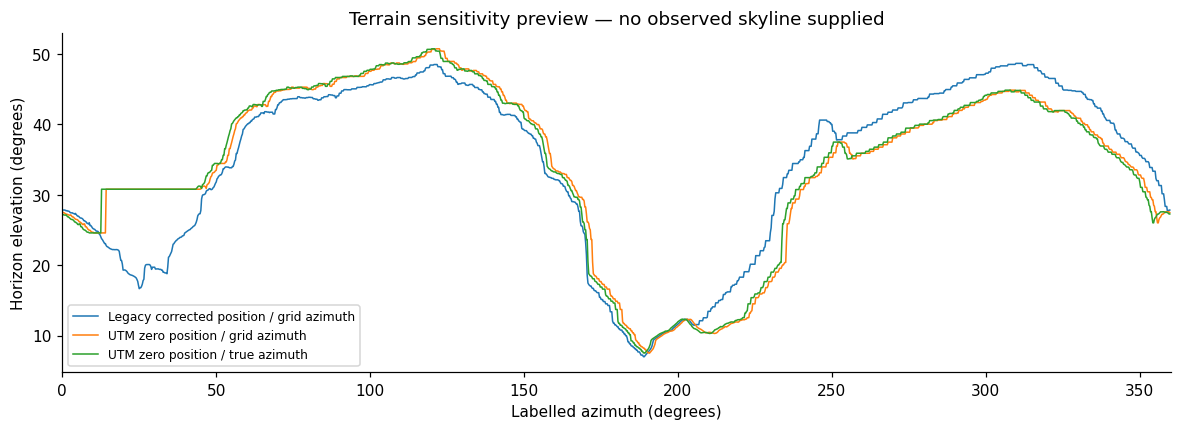

In [10]:
if RUN_HORIZON_PREVIEW:
    preview = copy.copy(dem)
    preview.data = dem.data[::PREVIEW_DECIMATION, ::PREVIEW_DECIMATION].copy()
    preview.res = dem.res*PREVIEW_DECIMATION
    old = positions[PREVIEW_OBSERVER]["Legacy corrected"]
    new = positions[PREVIEW_OBSERVER]["UTM zero"]
    z = sample_height(new)+2 if PREVIEW_OBSERVER_ALT_M is None else PREVIEW_OBSERVER_ALT_M
    print("Observer:", PREVIEW_OBSERVER, "; common absolute DEM-datum height:", z)
    print("Height above native terrain: legacy location", z-sample_height(old),
          "m; UTM location", z-sample_height(new), "m")
    if PREVIEW_OBSERVER_ALT_M is None:
        print("HYPOTHETICAL HEIGHT — replace with an independently known height for field comparison.")
    curves = {}
    for label, en, frame in [
        ("Legacy corrected position / grid azimuth", old, "grid"),
        ("UTM zero position / grid azimuth", new, "grid"),
        ("UTM zero position / true azimuth", new, "true"),
    ]:
        curves[label] = np.rad2deg(preview.calc_horizon(*en, z, n_az=PREVIEW_N_AZ,
                                                       azimuth_frame=frame)[0])
    fig, ax = plt.subplots(figsize=(13, 4))
    az = np.arange(PREVIEW_N_AZ)*360/PREVIEW_N_AZ
    for label,h in curves.items():
        ax.plot(az, h, lw=1, label=label)
    ax.set(xlim=(0,360), xlabel="Labelled azimuth (degrees)",
           ylabel="Horizon elevation (degrees)", title="Terrain sensitivity preview — no observed skyline supplied")
    ax.legend(fontsize=8); finish(fig, "07_horizon_sensitivity")
else:
    print("Horizon preview disabled in review inputs.")

In [11]:
print("REVIEW STATUS")
print("Mapping-equivalence translation added to UTM (m):", np.round(t_equiv, 3))
print("Not a field calibration; independent matches supplied:", len(MATCHES))
print("Independent observed bearings supplied:", len(OBSERVED_BEARINGS))
print("Diagnostic height RMS (m; vertical provenance unconfirmed):",
      {k: round(float(v), 3) for k,v in height_rms.items()})
if not MATCHES or not OBSERVED_BEARINGS:
    print("Physical survey alignment and/or field azimuth validation remain OPEN.")

REVIEW STATUS
Mapping-equivalence translation added to UTM (m): [ 3.7   26.348]
Not a field calibration; independent matches supplied: 0
Independent observed bearings supplied: 0
Diagnostic height RMS (m; vertical provenance unconfirmed): {'Legacy raw': 27.091, 'Legacy corrected': 14.919, 'UTM zero': 1.95}
Physical survey alignment and/or field azimuth validation remain OPEN.


## 11. Aaron's review record and decision

Fill this in alongside the reference input cells, then rerun and save outputs.

| Question | Notes / evidence |
|---|---|
| How was `[-11, 36, 3] m` derived? Which points, features, and original code/data? | Awaiting Aaron |
| Were offsets intended to correct GPS bias, image alignment, height, or the DEM? | Awaiting Aaron |
| GPS device, datum/epoch, estimated horizontal accuracy and repeatability? | Awaiting Aaron |
| Height source/datum, geoid correction, and instrument height above ground? | Awaiting Aaron |
| Which image features correspond to the actual survey marks (including A/B's ~3 m displacement)? | Awaiting Aaron |
| Which points were used for fitting, and which were held out? | Awaiting reference matches |
| Is photo/compass true-north orientation independently known? | Awaiting observed bearings |
| Does UTM zero improve held-out placement, or is a residual correction needed? | Unvalidated |
| Are alternative plausible feature matches consistent with that decision? | Unvalidated |
| Decision on PR's zero horizontal default and subsequent calibration? | Pending review |

**What this notebook can establish now:** the size and spatial pattern of the
coordinate change, the consequences for terrain sampling, and the correctness
of the true/grid azimuth sign against a geodesic calculation.

**What it cannot establish without references:** that UTM zero gives more accurate
physical survey placements, the numerical residual field offset, or agreement
with an observed skyline. The old correction should not be called obsolete on
empirical grounds until these checks are complete. Reusing it unchanged in UTM
also lacks justification; a calibration must be expressed in the new frame.

Attach notes/images by adding Markdown cells next to the relevant local plot,
and record each match's provenance in `MATCHES`. Keep the original coordinates
and images so someone else can review the judgments. Exporting this notebook to
HTML preserves the executed figures for review without a Python environment.